In [1]:
#importing packages and libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.io.wavfile as wavfile
import librosa
import librosa.display
from matplotlib import patches

In [2]:
#upload and load a speech file
import scipy.io.wavfile as wavfile
filename = "/Users/soujanyabhat/Downloads/exam-3-input.wav"

#read the file
fs, speech_signal = wavfile.read(filename)

print(f"Sampling rate: {fs} Hz")
print(f"Signal shape: {speech_signal.shape}")

Sampling rate: 44100 Hz
Signal shape: (183015, 2)


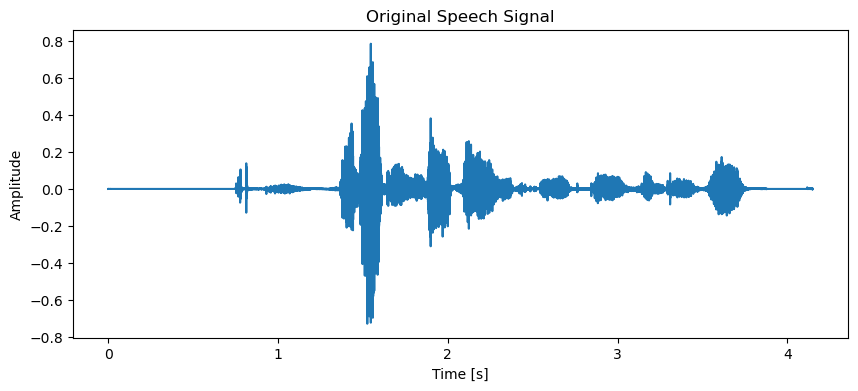

In [3]:
#preprocess the signal
#converting stereo to mono if required
if speech_signal.ndim > 1:
    speech_signal = speech_signal.mean(axis=1)

#normalise amplitude
speech_signal = speech_signal / np.max(np.abs(speech_signal))

#pre-emphasis to enhance higher frequencies
speech_signal = signal.lfilter([1, -0.97], [1], speech_signal)

#plotting waveform
plt.figure(figsize=(10,4))
plt.plot(np.linspace(0, len(speech_signal)/fs, num=len(speech_signal)), speech_signal)
plt.title('Original Speech Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.show()

In [4]:
#lpc computation 
frame_length = 2048
speech_frame = speech_signal[:frame_length] * np.hamming(frame_length)
order = 12 #LPC order

lpc_coeffs = librosa.lpc(speech_frame, order=order)
print("LPC Coefficients")
print(lpc_coeffs)

LPC Coefficients
[1.         0.95211518 0.81392142 0.70177554 0.62158903 0.58978223
 0.50559597 0.41958294 0.34884044 0.26719937 0.19236896 0.12692688
 0.04697909]


Text(0, 0.5, 'Amplitude')

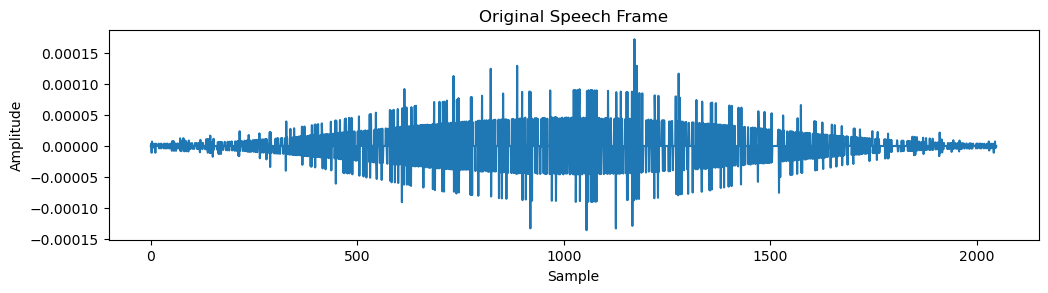

In [5]:
#reconstructing the original signal using LPC
residual = signal.lfilter(lpc_coeffs, [1], speech_frame)
reconstructed_signal = signal.lfilter([1], lpc_coeffs, residual)

plt.figure(figsize=(12,6))
plt.subplot(2, 1, 1)
plt.plot(speech_frame)
plt.title('Original Speech Frame')
plt.xlabel('Sample')
plt.ylabel('Amplitude')

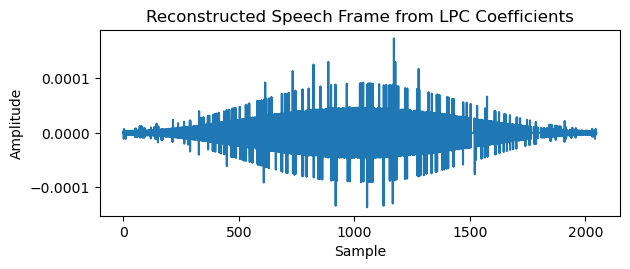

In [6]:
plt.subplot(2,1,2)
plt.plot(reconstructed_signal)
plt.title('Reconstructed Speech Frame from LPC Coefficients')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [14]:
#estimating the formants (resonant frequencies)
rts = np.roots(lpc_coeffs)
rts = [r for r in rts if np.abs(r) < 1] #keeping stable poles
angz = np.angle(rts)
frequencies = angz * (fs / (2 * np.pi))
frequencies = frequencies[frequencies>90] #remove low freqs
frequencies = np.sort(frequencies)
formants = frequencies[:4]

print("\nEstimated Formant Frequencies(Hz): ")
for idx, freq in enumerate(formants):
    print(f"Formant F{idx+1}: {freq:2f} Hz")


Estimated Formant Frequencies(Hz): 
Formant F1: 3940.487719 Hz
Formant F2: 7268.128681 Hz
Formant F3: 10820.694130 Hz
Formant F4: 14134.860274 Hz


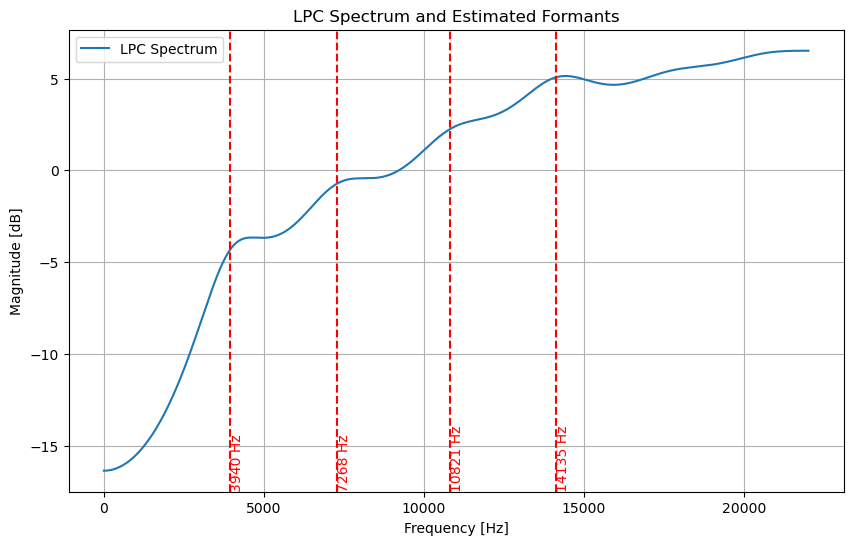

In [8]:
#plotting LPC spectrum and formants 
w, h = signal.freqz(1, lpc_coeffs, worN=512, fs=fs)
plt.figure(figsize=(10,6))
plt.plot(w, 20 * np.log10(np.abs(h)), label='LPC Spectrum')
plt.title("LPC Spectrum and Estimated Formants")
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.grid(True)
for freq in formants:
    plt.axvline(x=freq, color='red', linestyle='--')
    plt.text(freq, plt.ylim()[0], f'{freq:.0f} Hz', rotation=90, color='red', verticalalignment='bottom')

plt.legend()
plt.show()


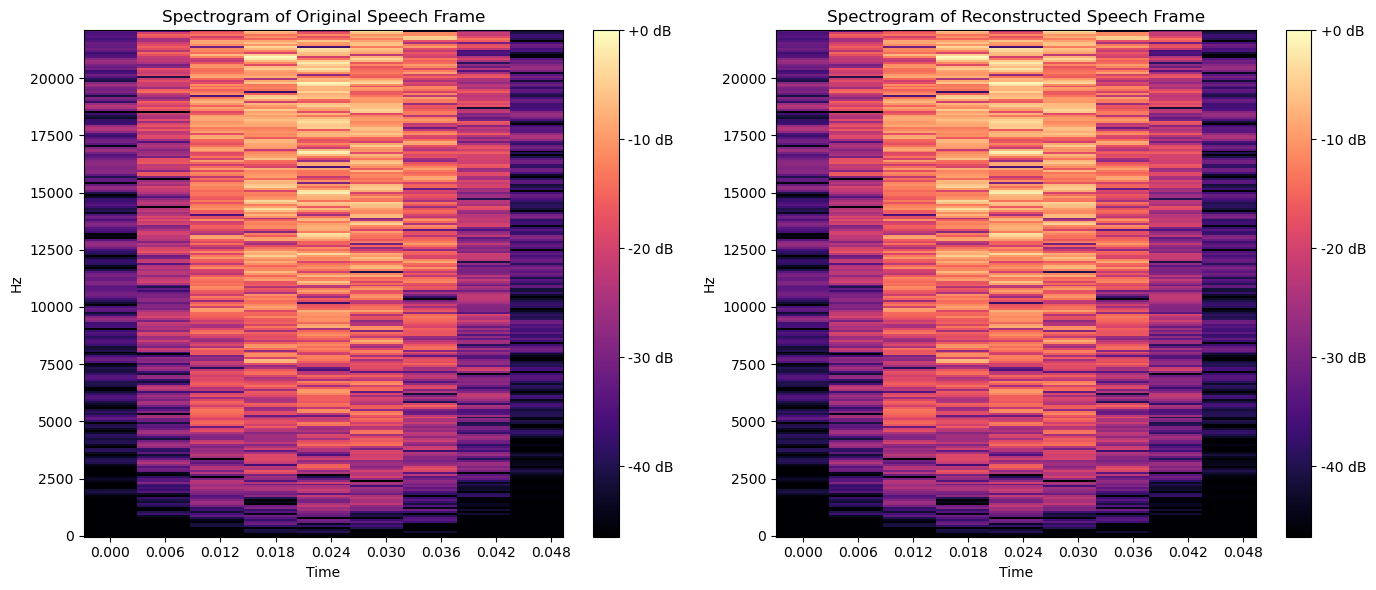

In [12]:
#spectogram comparison
n_fft = 512
hop_length = 256
S_original = np.abs(librosa.stft(speech_frame, n_fft=n_fft, hop_length=hop_length))
S_reconstructed = np.abs(librosa.stft(reconstructed_signal, n_fft=n_fft, hop_length=hop_length))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
librosa.display.specshow(librosa.amplitude_to_db(S_original, ref=np.max),
                         sr=fs, hop_length=hop_length, x_axis='time', y_axis='linear')
plt.title('Spectrogram of Original Speech Frame')
plt.colorbar(format='%+2.0f dB')

plt.subplot(1, 2, 2)
librosa.display.specshow(librosa.amplitude_to_db(S_reconstructed, ref=np.max),
                         sr=fs, hop_length=hop_length, x_axis='time', y_axis='linear')
plt.title('Spectrogram of Reconstructed Speech Frame')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

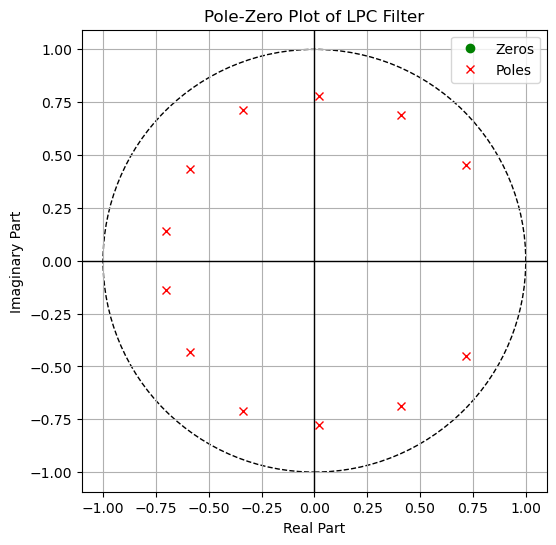

In [13]:
#pole-zero plot
def zplane(b, a, title='Pole-Zero Plot'):
    plt.figure(figsize=(6, 6))
    zeros = np.roots(b)
    poles = np.roots(a)
    uc = patches.Circle((0,0), radius=1, fill=False, color='black', ls='dashed')
    plt.gca().add_patch(uc)
    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.plot(np.real(zeros), np.imag(zeros), 'go', label='Zeros')
    plt.plot(np.real(poles), np.imag(poles), 'rx', label='Poles')
    plt.title(title)
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

zplane([1], lpc_coeffs, title='Pole-Zero Plot of LPC Filter')